<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  5.37MB/s    in 32s     

2026-09-15 13:01:41 (6.32 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


In [11]:
!pip install seaborn
!pip install numpy
import seaborn as sns
import numpy as np

#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


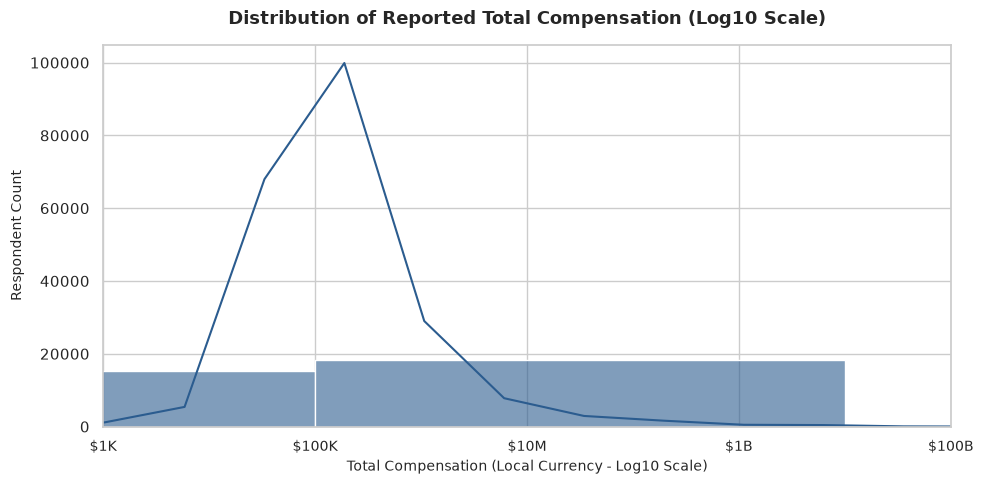

In [12]:
## Write your code here
sns.set_theme(style="whitegrid", font="sans-serif")

query = """
SELECT CompTotal 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0
"""
comp_total = pd.read_sql_query(query, conn)

log_vals = np.log10(comp_total["CompTotal"].dropna())

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    log_vals,
    kde=True,
    color="#2b5c8f",
    bins=30,
    edgecolor="white",
    alpha=0.6,
    ax=ax,
)

ax.set_xlim(3, 11)

fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]
ax.minorticks_off()
ax.set_xticks(fixed_ticks)
ax.set_xticklabels(fixed_labels, fontsize=10, fontweight="normal")

plt.title(
    "Distribution of Reported Total Compensation (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Compensation (Local Currency - Log10 Scale)", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


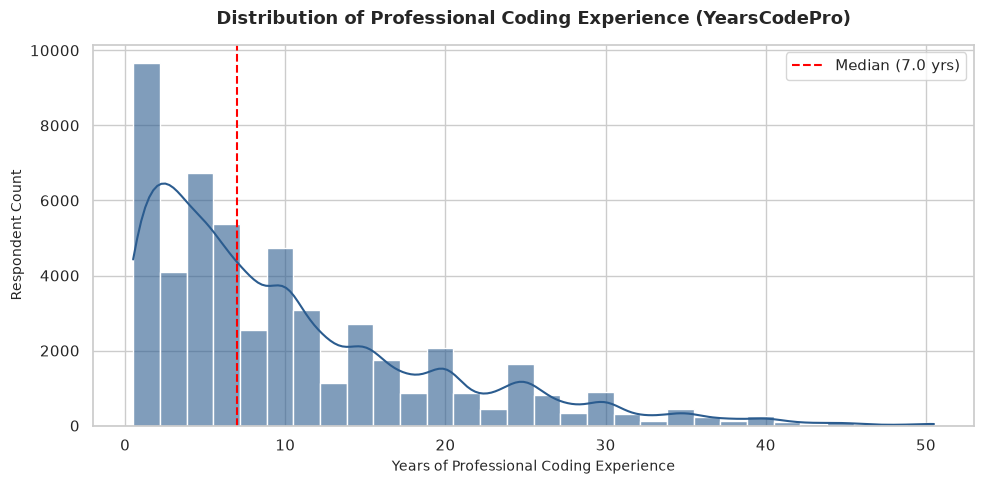

In [13]:
## Write your code here
# Query YearsCodePro from SQLite database
query = """
SELECT YearsCodePro 
FROM main 
WHERE YearsCodePro IS NOT NULL
"""
df_experience = pd.read_sql_query(query, conn)

# Clean special text entries to numeric values
df_experience["YearsCodePro"] = df_experience["YearsCodePro"].replace(
    {"Less than 1 year": "0.5", "More than 50 years": "50.5"}
)

# Convert to numeric float and drop NaNs
df_experience["YearsCodePro"] = pd.to_numeric(
    df_experience["YearsCodePro"], errors="coerce"
)
df_clean = df_experience.dropna(subset=["YearsCodePro"])

# Plot Histogram
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="YearsCodePro",
    kde=True,
    color="#2b5c8f",
    bins=30,
    edgecolor="white",
    alpha=0.6,
)

# Annotate median experience value
median_exp = df_clean["YearsCodePro"].median()
plt.axvline(
    median_exp,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Median ({median_exp:.1f} yrs)",
)

plt.title(
    "Distribution of Professional Coding Experience (YearsCodePro)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Years of Professional Coding Experience", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

We can see that the number of respondents drops with the increase of their professional working experience

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


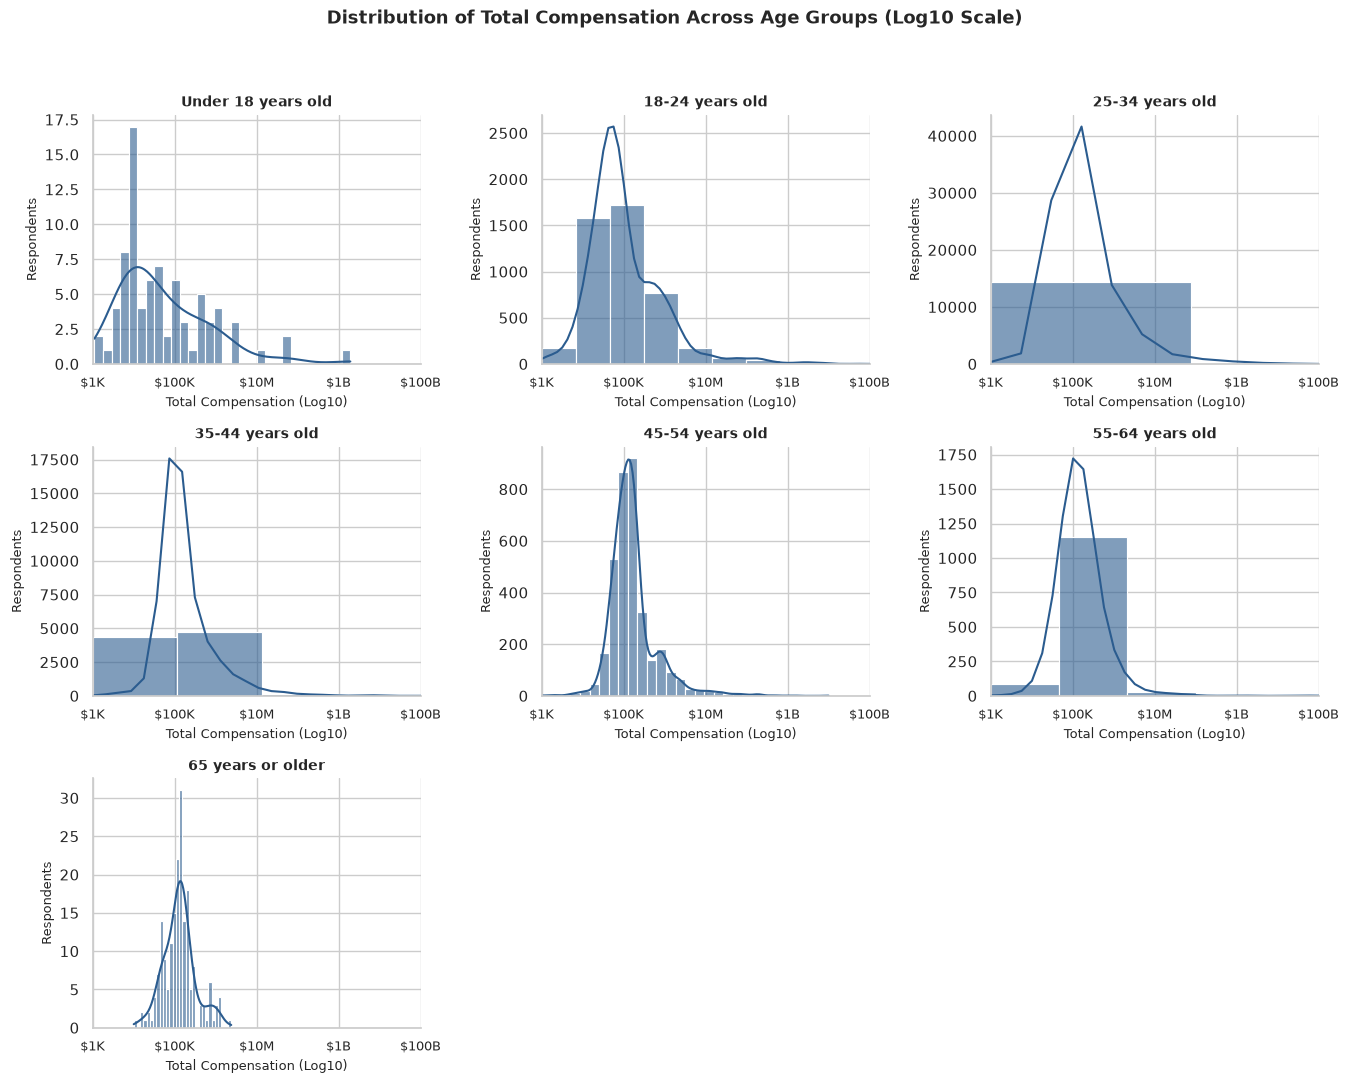

In [17]:
# Query CompTotal and Age from SQLite database
query = """
SELECT CompTotal, Age 
FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal >= 1000 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_comp_age = pd.read_sql_query(query, conn)

# Map categorical age strings to numeric midpoints
age_numeric_map = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 68,
}
df_comp_age["Age_Numeric"] = df_comp_age["Age"].map(age_numeric_map)

# Calculate explicit log10 values of compensation beforehand
df_comp_age["log_CompTotal"] = np.log10(df_comp_age["CompTotal"])

# Chronological category ordering for facets
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Render facet grid of histograms across age categories
g = sns.FacetGrid(
    data=df_comp_age,
    col="Age",
    col_order=age_order,
    col_wrap=3,
    height=3.5,
    aspect=1.3,
    sharey=False,
    sharex=False
)

g.map_dataframe(
    sns.histplot,
    x="log_CompTotal",
    bins=30,
    color="#2b5c8f",
    edgecolor="white",
    alpha=0.6,
    kde=True,
)

# Hardcode x-ticks and formatting across all subplot facets
fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

for ax in g.axes.flat:
    ax.set_xlim(3, 11)
    ax.set_xticks(fixed_ticks)
    ax.set_xticklabels(fixed_labels, fontsize=9)
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Total Compensation (Log10)", fontsize=9)
    ax.set_ylabel("Respondents", fontsize=9)

g.set_titles(col_template="{col_name}", size=10, weight="bold")
g.fig.suptitle(
    "Distribution of Total Compensation Across Age Groups (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()
plt.show()

We can see that the most respondents are in the 25-34 age group, followed by 35-44 and in bothe the peak of the distribution curve occurs around 100K$.

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


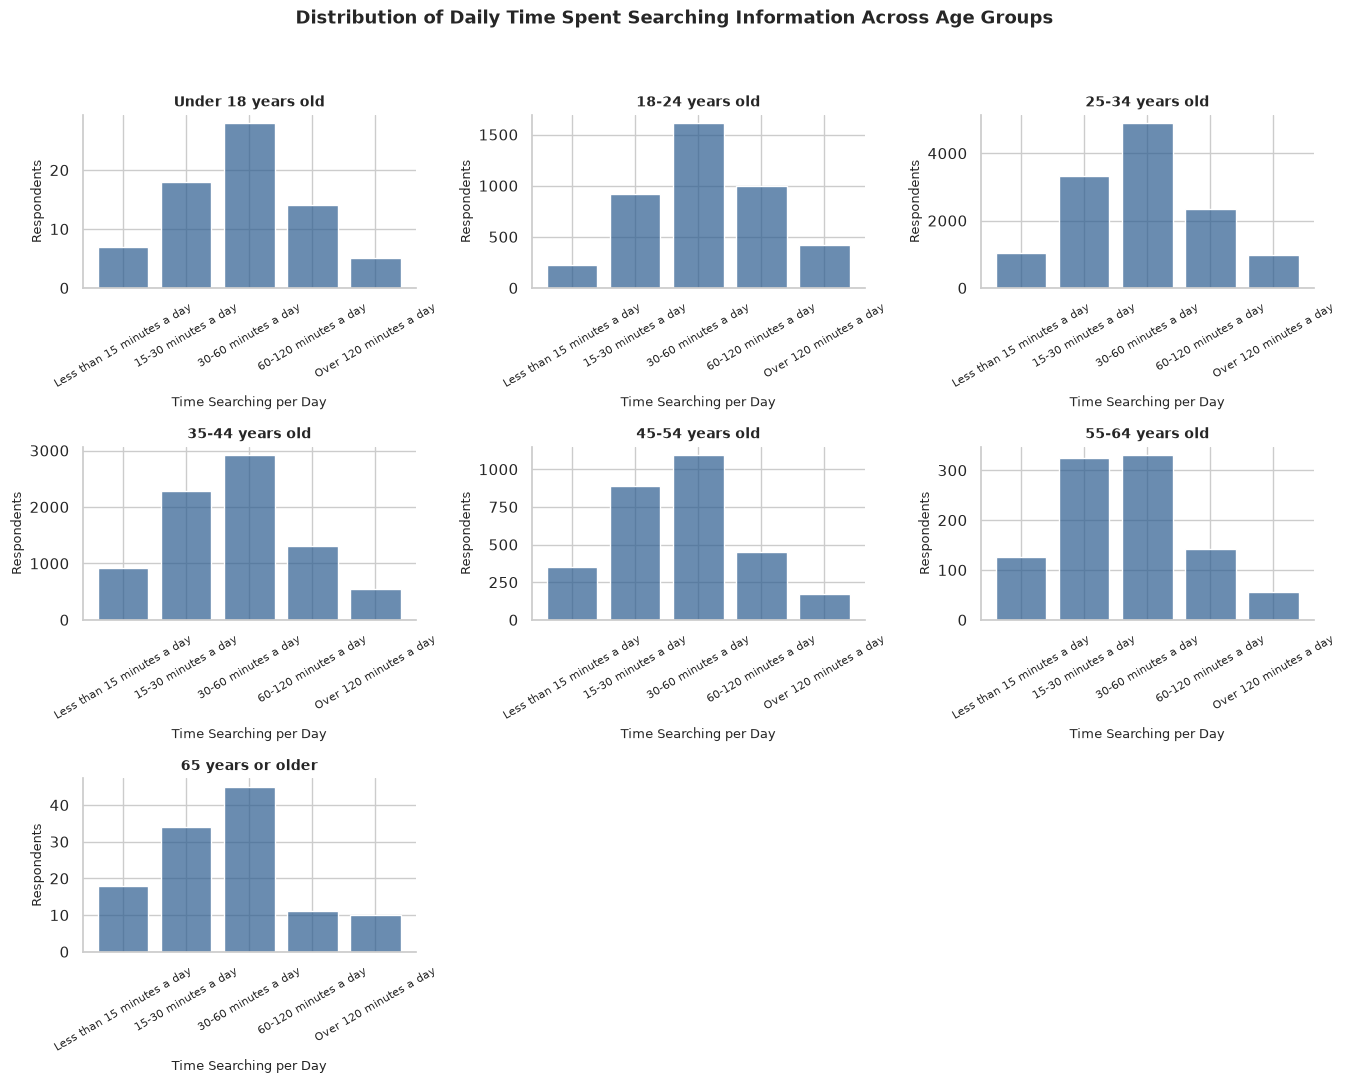

In [18]:
## Write your code here
# Query TimeSearching and Age from SQLite database
query = """
SELECT TimeSearching, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Age IS NOT NULL 
  AND Age != 'Prefer not to say'
"""
df_search_age = pd.read_sql_query(query, conn)

# Standardize text category order for TimeSearching
search_order = [
    "Less than 15 minutes a day",
    "15-30 minutes a day",
    "30-60 minutes a day",
    "60-120 minutes a day",
    "Over 120 minutes a day",
]

# Chronological category order for Age facets
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Filter to keep standard categorical values and apply categorical type
df_search_age = df_search_age[
    df_search_age["TimeSearching"].isin(search_order)
].copy()
df_search_age["TimeSearching"] = pd.Categorical(
    df_search_age["TimeSearching"], categories=search_order, ordered=True
)

# Render FacetGrid of categorical histograms (bar distributions) across age groups
g = sns.FacetGrid(
    data=df_search_age,
    col="Age",
    col_order=age_order,
    col_wrap=3,
    height=3.5,
    aspect=1.3,
    sharex=False,
    sharey=False,
)

g.map_dataframe(
    sns.histplot,
    x="TimeSearching",
    color="#2b5c8f",
    edgecolor="white",
    alpha=0.7,
    shrink=0.8,
)

# Format ticks and labels across all subplots
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Time Searching per Day", fontsize=9)
    ax.set_ylabel("Respondents", fontsize=9)

g.set_titles(col_template="{col_name}", size=10, weight="bold")
g.fig.suptitle(
    "Distribution of Daily Time Spent Searching Information Across Age Groups",
    fontsize=13,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()
plt.show()

We can see that for all age groups the most common time spent searching for information is 30-60 min a day, followed by 15-30 min. And the least common is over 120 min a day.

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


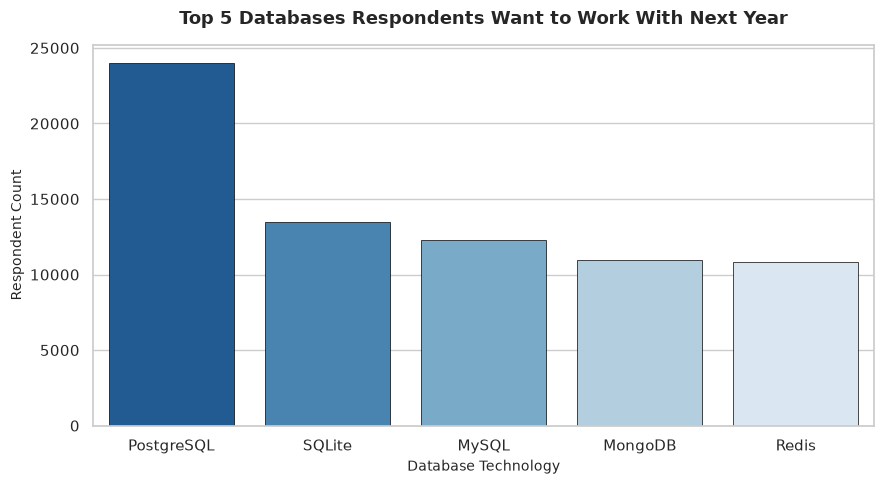

In [20]:
# Query DatabaseWantToWorkWith from SQLite database
query = """
SELECT DatabaseWantToWorkWith 
FROM main 
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df_db = pd.read_sql_query(query, conn)

# Split semi-colon delimited survey responses and count occurrences
df_db_exploded = df_db["DatabaseWantToWorkWith"].str.split(";").explode()
df_db_exploded = df_db_exploded.str.strip()

# Extract top 5 databases into a DataFrame
top_5_db = df_db_exploded.value_counts().head(5).reset_index()
top_5_db.columns = ["Database", "Count"]

# Render Bar Chart of Top 5 Databases (No Warnings)
plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_5_db,
    x="Database",
    y="Count",
    hue="Database",
    legend=False,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Top 5 Databases Respondents Want to Work With Next Year",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Database Technology", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

The most wanted database is PostgreSQL an open source db with great features, rich extension ecosystem and strong community. Followed by SQLite with its zero-configuration, file-based architecture which makes it the default choice for lightweight local storage, mobile apps, desktop software, and web applications alike.

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


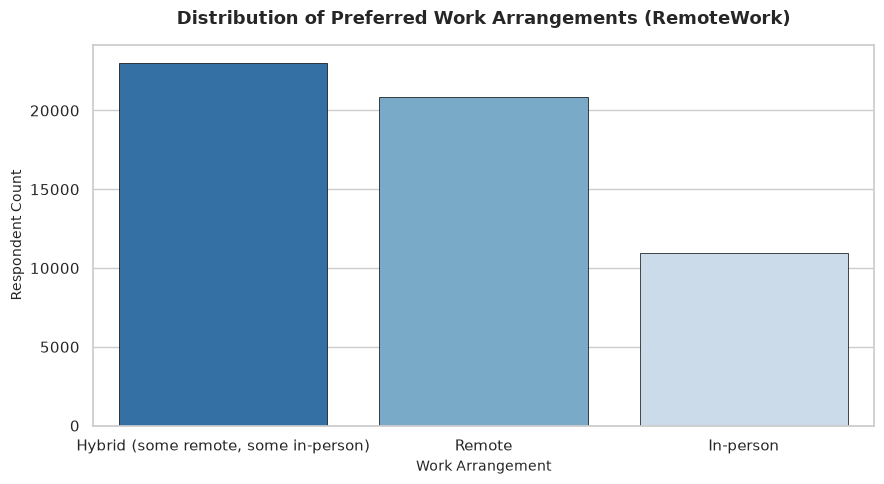

In [21]:
## Write your code here
# Query RemoteWork column from SQLite database
query = """
SELECT RemoteWork 
FROM main 
WHERE RemoteWork IS NOT NULL
"""
df_remote = pd.read_sql_query(query, conn)

# Count occurrences for each work arrangement
remote_counts = df_remote["RemoteWork"].value_counts().reset_index()
remote_counts.columns = ["RemoteWork", "Count"]

# Plot Distribution Histogram / Bar Plot (No Warnings)
plt.figure(figsize=(9, 5))

sns.barplot(
    data=remote_counts,
    x="RemoteWork",
    y="Count",
    hue="RemoteWork",
    legend=False,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Distribution of Preferred Work Arrangements (RemoteWork)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Work Arrangement", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

We can see that the most popular option is a hybrid work arrangement, followed closely by totaly remote while traditional in-office requirements lag significantly behind.

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


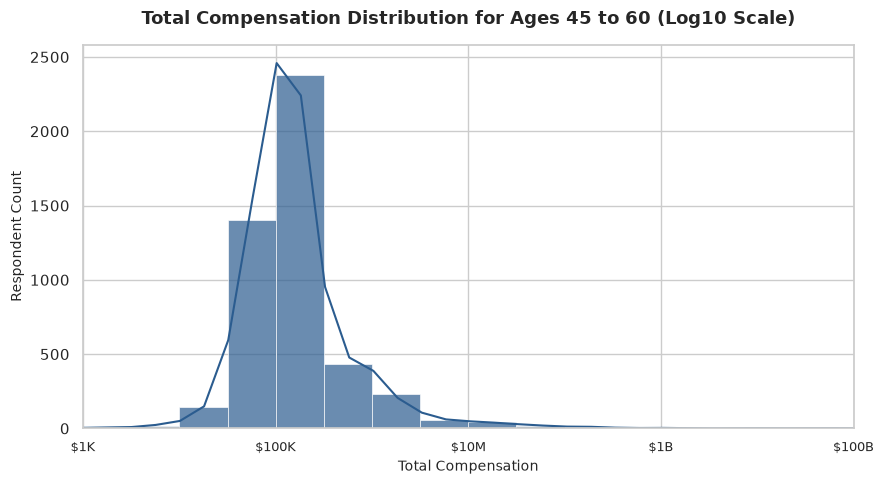

In [23]:
## Write your code here
# Query CompTotal for developers aged 45 to 60
query = """
SELECT CompTotal, Age 
FROM main 
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL 
  AND CompTotal >= 1000
"""
df_midcareer = pd.read_sql_query(query, conn)

# Apply log10 transformation to handle wide compensation variance
df_midcareer["log_CompTotal"] = np.log10(df_midcareer["CompTotal"])

# Render Histogram
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_midcareer,
    x="log_CompTotal",
    bins=100,
    color="#2b5c8f",
    edgecolor="white",
    alpha=0.7,
    kde=True,
)

# Hardcode x-ticks for log10 compensation scale
fixed_ticks = [3, 5, 7, 9, 11]
fixed_labels = ["$1K", "$100K", "$10M", "$1B", "$100B"]

plt.xticks(fixed_ticks, fixed_labels, fontsize=9)
plt.xlim(3, 11)

plt.title(
    "Total Compensation Distribution for Ages 45 to 60 (Log10 Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Compensation", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()


The peak of the distribution is around `\$100K` and most of the responders are in the `\$90K - \$300K` bin.

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


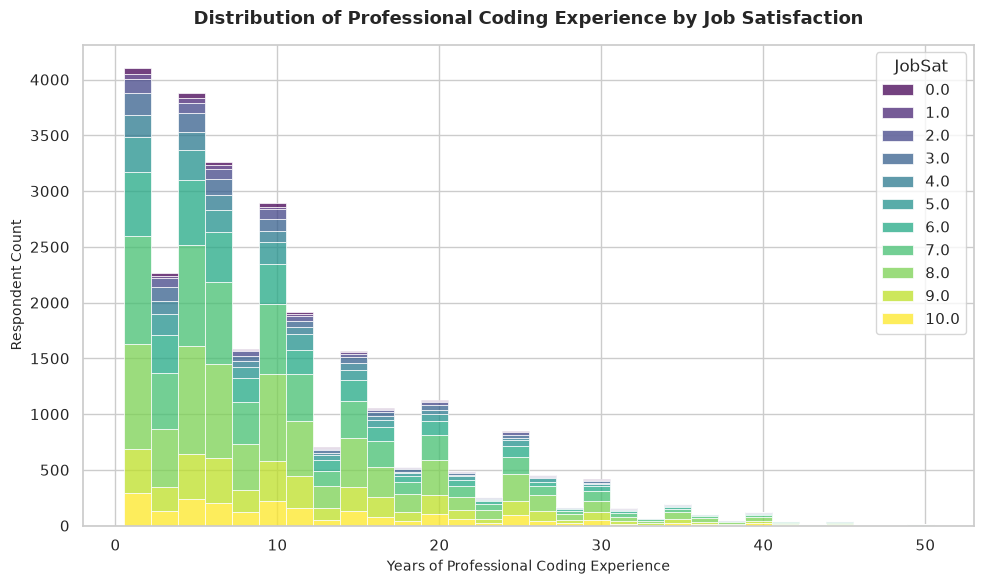

In [24]:
## Write your code here
# Query JobSat and YearsCodePro from SQLite database
query = """
SELECT JobSat, YearsCodePro 
FROM main 
WHERE JobSat IS NOT NULL 
  AND YearsCodePro IS NOT NULL
"""
df_jobsat = pd.read_sql_query(query, conn)

# Clean special text entries in YearsCodePro
df_jobsat["YearsCodePro"] = df_jobsat["YearsCodePro"].replace(
    {"Less than 1 year": "0.5", "More than 50 years": "50.5"}
)

# Convert YearsCodePro to numeric float and drop non-convertible rows
df_jobsat["YearsCodePro"] = pd.to_numeric(
    df_jobsat["YearsCodePro"], errors="coerce"
)
df_jobsat_clean = df_jobsat.dropna(subset=["YearsCodePro"]).copy()

# Render FacetGrid or Grouped Histogram for JobSat across Experience Levels
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_jobsat_clean,
    x="YearsCodePro",
    hue="JobSat",
    bins=30,
    multiple="stack",
    palette="viridis",
    edgecolor="white",
    linewidth=0.5,
)

plt.title(
    "Distribution of Professional Coding Experience by Job Satisfaction",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Years of Professional Coding Experience", fontsize=10)
plt.ylabel("Respondent Count", fontsize=10)

plt.tight_layout()
plt.show()

We can observe those patterns:
* Central Tendency Bias: Survey respondents naturally cluster around 5–6 (or "Slightly satisfied" / "Neither satisfied nor dissatisfied"), as people tend to avoid extreme scores unless they are exceptionally happy or unhappy.

* Survival / Tenure Bias: The rarity of low satisfaction scores in higher experience brackets (30+ years) is often driven by workforce selection—developers who are deeply dissatisfied with their careers tend to transition into other roles or management over time, leaving those with higher baseline satisfaction in long-term engineering roles.

* Sample Size Shrinkage: The sheer volume of respondents drops significantly past 30 years of professional coding, making the tail end of the distribution much sparser. 

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [26]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
